**=======INSTALLING AND IMPORTING LIBRARIES=======**

In [1]:
!pip install pytrends pandas matplotlib seaborn

In [2]:
from pytrends.request import TrendReq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pytrends = TrendReq(hl='en-US', tz=330)

**======TAKING KEYWORD FROM USER======**

In [4]:
keywords = input(
    "Enter keywords separated by commas: "
)

keywords = [
    k.strip()
    for k in keywords.split(",")
]

print(keywords)

Enter keywords separated by commas: Python, java, C++
['Python', 'java', 'C++']


**======FETCHING GOOGLE TRENDS DATA======**

In [6]:
pytrends.build_payload(
    keywords,
    timeframe='today 5-y'
)

trend_data = pytrends.interest_over_time()

#view data
trend_data.head()

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


,Python,java,C++,isPartial
date,,,,
2021-05-23,17,14,63,False
2021-05-30,17,15,61,False
2021-06-06,17,15,63,False
2021-06-13,17,14,63,False
2021-06-20,17,15,63,False


In [7]:
print(trend_data.shape)
print(trend_data.columns)
trend_data.info

(262, 4)
Index(['Python', 'java', 'C++', 'isPartial'], dtype='object')


<bound method DataFrame.info of             Python  java  C++  isPartial
date                                    
2021-05-23      17    14   63      False
2021-05-30      17    15   61      False
2021-06-06      17    15   63      False
2021-06-13      17    14   63      False
2021-06-20      17    15   63      False
...            ...   ...  ...        ...
2026-04-26      25    15   95      False
2026-05-03      30    15  100      False
2026-05-10      20    12   78      False
2026-05-17      16    11   74      False
2026-05-24      14    10   73       True

[262 rows x 4 columns]>

**======PLOT SEARCH INTERESTS OVER TIME======**

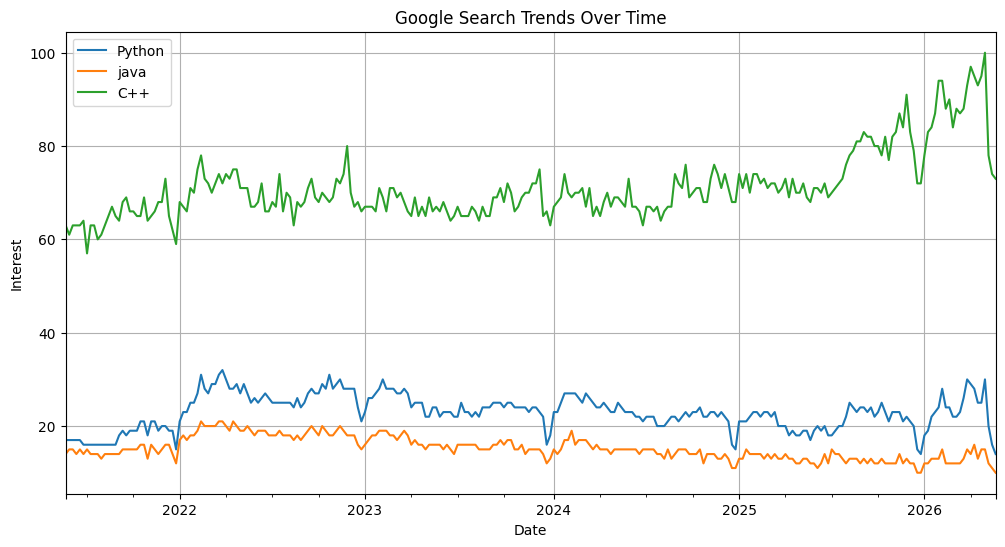

In [8]:
trend_data[keywords].plot(
    figsize=(12,6)
)

plt.title(
    "Google Search Trends Over Time"
)

plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)

plt.show()

**======REGION-WISE ANALYSIS======**

In [11]:
region_data = pytrends.interest_by_region()

region_data.head()



,Python,java,C++
geoName,,,
Afghanistan,0,0,0
Albania,0,0,0
Algeria,17,9,74
American Samoa,0,0,0
Andorra,0,0,0


In [12]:
#top regions
for keyword in keywords:

    print("\nTop Regions for", keyword)

    print(
        region_data
        .sort_values(
            by=keyword,
            ascending=False
        )
        .head(10)
    )


Top Regions for Python
             Python  java  C++
geoName                       
China            53    29   18
Israel           48    16   36
Russia           41    18   41
Kazakhstan       38    14   48
Singapore        38    16   46
Iran             36    11   53
Uzbekistan       36    20   44
South Korea      35    21   44
Hong Kong        33    15   52
Ukraine          33    19   48

Top Regions for java
             Python  java  C++
geoName                       
China            53    29   18
Belarus          30    27   43
Bulgaria         26    24   50
India            25    23   52
South Korea      35    21   44
Uzbekistan       36    20   44
Ukraine          33    19   48
Philippines      12    18   70
Russia           41    18   41
Kenya            21    17   62

Top Regions for C++
              Python  java  C++
geoName                        
Italy             10     7   83
Brazil            11     9   80
South Africa      13     8   79
Indonesia          8    14   

**======VISUALIZING TOP REGIONS======**

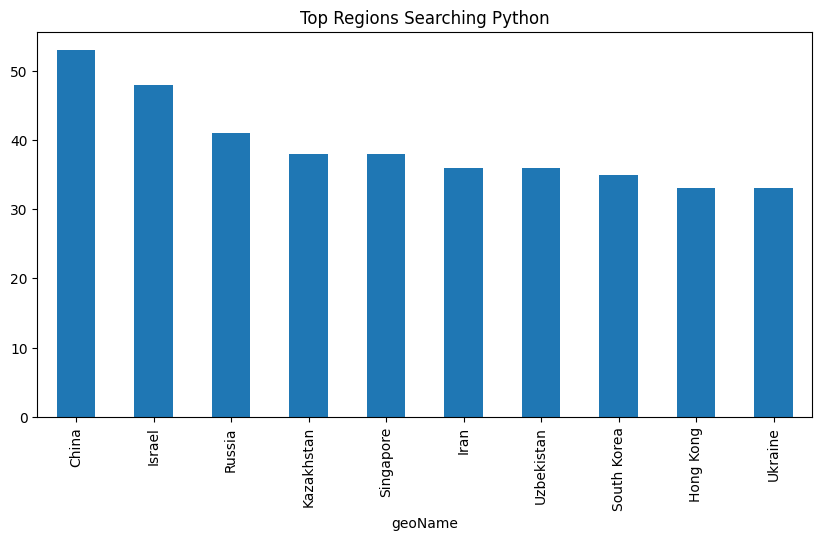

In [13]:
top_regions = (
    region_data
    .sort_values(
        by=keywords[0],
        ascending=False
    )
    .head(10)
)

top_regions[keywords[0]].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    f"Top Regions Searching {keywords[0]}"
)

plt.show()

**======RELATED QUESRIES======**

In [15]:
related_queries = pytrends.related_queries()

for keyword in keywords:

    print(f"\nRelated Queries for {keyword}")

    if keyword in related_queries and 'top' in related_queries[keyword]:
        print(
            related_queries[keyword]['top']
        )
    else:
        print(f"No top related queries found for {keyword}")


Related Queries for Python
                     query  value
0              python list    100
1              python code     74
2            python online     59
3           install python     52
4           what is python     50
5          download python     42
6            python pandas     38
7                   pandas     36
8          python compiler     32
9             python print     30
10              python set     29
11       python dictionary     27
12            python class     26
13                  github     24
14  python online compiler     21
15      python programming     21
16                   numpy     18
17            monty python     17
18             ball python     16
19                    java     16
20         python tutorial     15
21            python range     14
22    python documentation     14
23                  vscode     14
24            learn python     13

Related Queries for java
                      query  value
0            java minecraft

In [16]:
related_topics = pytrends.related_topics()

print(related_topics)

{}


**======CORRELATION BETWEEN KEYWORDS======**

In [18]:
correlation = trend_data[
    keywords
].corr()

print(correlation)

          Python      java       C++
Python  1.000000  0.732793  0.284862
java    0.732793  1.000000 -0.225793
C++     0.284862 -0.225793  1.000000


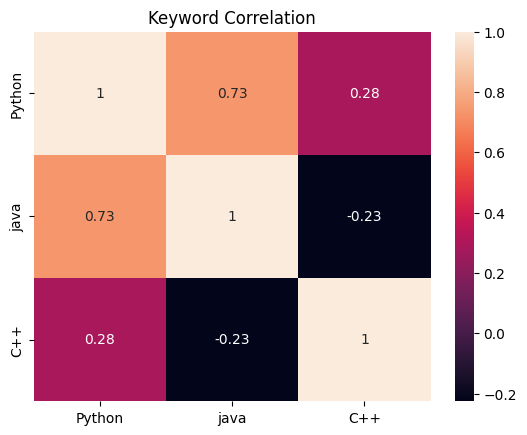

In [19]:
sns.heatmap(
    correlation,
    annot=True
)

plt.title(
    "Keyword Correlation"
)

plt.show()

**======SAVING DATASET======**

In [20]:
trend_data.to_csv(
    "google_trends_data.csv"
)

In [21]:
from google.colab import files

files.download(
    "google_trends_data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 1200x600 with 0 Axes>

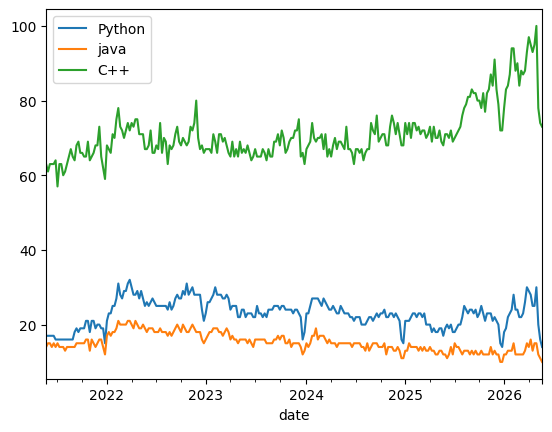

In [22]:
plt.figure(
    figsize=(12,6)
)

trend_data[keywords].plot()

plt.savefig(
    "trend_graph.png"
)